# Data Cleaning (Graph Creation)

- I've already got a graph of walking paths and nodes. 
- I need to add the grocery stores to their nearest node in the graph. 
- I'll do the same with the tracts and the bus stops.
- I'll make each edge weighted by its walk time (~1.34 m/s = 3 mph).

## 0. Setup

In [49]:
import osmnx as ox
import geopandas as gpd
import networkx as nx

PROJECTION = "epsg:4326"
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

walk_graph = ox.load_graphml(f"{RAW_DIR}/kingstowne_walk_network.graphml")
bus_stops = gpd.read_file(f"{RAW_DIR}/kingstowne_stops.geojson")
stores = gpd.read_file(f"{RAW_DIR}/kingstowne_pois.geojson")
tracts = gpd.read_file(f"{PROCESSED_DIR}/kingstowne_tracts_demographics.geojson")

## 1. Nearest Nodes
https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.distance.nearest_nodes

In [50]:
# CRS conversions (nearest_nodes expects coordinates in EPSG:4326
stores.to_crs(epsg=4326, inplace=True)
bus_stops.to_crs(epsg=4326, inplace=True)
tracts.to_crs(epsg=4326, inplace=True)

In [51]:
stores["nearest_node"] = ox.distance.nearest_nodes(walk_graph, stores.geometry.x, stores.geometry.y)
bus_stops["nearest_node"] = ox.distance.nearest_nodes(walk_graph, bus_stops.geometry.x, bus_stops.geometry.y)

projected_tracts = tracts.to_crs(epsg=32618) # 32618 = 18N
tracts["centroid"] = projected_tracts.geometry.centroid
tracts["centroid"] = gpd.GeoSeries(tracts["centroid"], crs=32618).to_crs(4326)
tracts["nearest_node"] = ox.distance.nearest_edges(walk_graph, tracts["centroid"].x, tracts["centroid"].y)


## 2. Edge weights

In [52]:
print(walk_graph.edges)

[(63377895, 10964284767, 0), (63384919, 2130235717, 0), (63384919, 63781683, 0), (63384919, 8447857061, 0), (63384919, 2130235741, 0), (63416007, 1580635333, 0), (63416007, 2130235348, 0), (63416007, 1580635334, 0), (63432228, 63432230, 0), (63432230, 63432228, 0), (63432230, 63569841, 0), (63432230, 4763116647, 0), (63432271, 1614487149, 0), (63432271, 9378014707, 0), (63432271, 7114700579, 0), (63432271, 1614487126, 0), (63432271, 13283971267, 0), (63432280, 1614487185, 0), (63432280, 1614487197, 0), (63432280, 1614487171, 0), (63432285, 2129824060, 0), (63432285, 1550818627, 0), (63432285, 5618333990, 0), (63432287, 2129824067, 0), (63432287, 2130235446, 0), (63432287, 2130235446, 1), (63434678, 7068251561, 0), (63434678, 63672964, 0), (63439931, 63439932, 0), (63439932, 63439933, 0), (63439932, 63439931, 0), (63439932, 63439938, 0), (63439932, 63703745, 0), (63439933, 63439932, 0), (63439936, 63439938, 0), (63439938, 63439936, 0), (63439938, 63439932, 0), (63439938, 63439943, 0), (

In [53]:
for node, neighbor, key, data in walk_graph.edges(keys=True, data=True):
    data["walk_time"] = data["length"] / 1.34

In [54]:
missing_weight = sum(1 for node, neighbor, data in walk_graph.edges(data=True) if "walk_time" not in data)
print(f"Edges missing walk_time: {missing_weight}")

zero_length = sum(1 for node, neighbor, data in walk_graph.edges(data=True) if data.get("length", 0) == 0)
print(f"Edges with zero length: {zero_length}")

Edges missing walk_time: 0
Edges with zero length: 0


## 3. Check for graph connectivity
Find out how many connected components exist in the graph. There is only 1 connected component, which indicates that for every pair of nodes in the walk graph, there is a path of edges between them.

In [55]:
undirected_walk_graph = walk_graph.to_undirected()
components = list(nx.connected_components(undirected_walk_graph))
print(f"Number of connected components: {len(components)}")

Number of connected components: 1


## 4. Save files

In [56]:
ox.save_graphml(walk_graph, f"{PROCESSED_DIR}/kingstowne_walk_network_weighted.graphml")

stores.to_file(f"{PROCESSED_DIR}/pois_snapped.geojson", driver="GeoJSON")
bus_stops.to_file(f"{PROCESSED_DIR}/stops_snapped.geojson", driver="GeoJSON")
tracts.drop(columns="centroid").to_file(
    f"{PROCESSED_DIR}/tracts_snapped.geojson", driver="GeoJSON"
)

## 5. Visualize!

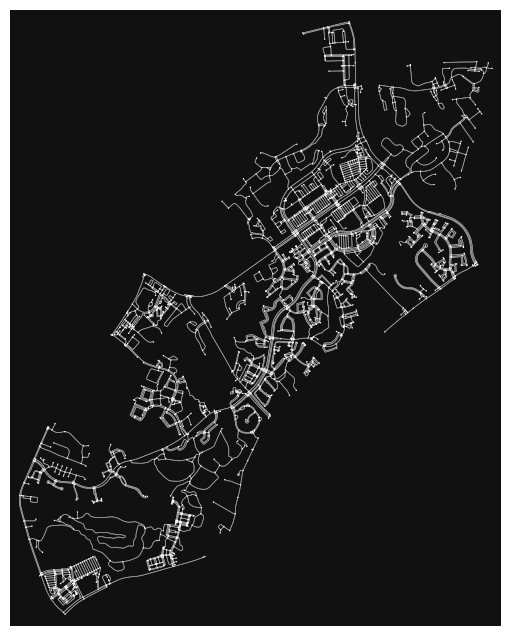

In [57]:
# Graph 1: just the walk_graph
fig, ax = ox.plot_graph(walk_graph, node_size=1, edge_linewidth=0.5, show=True, close=False)

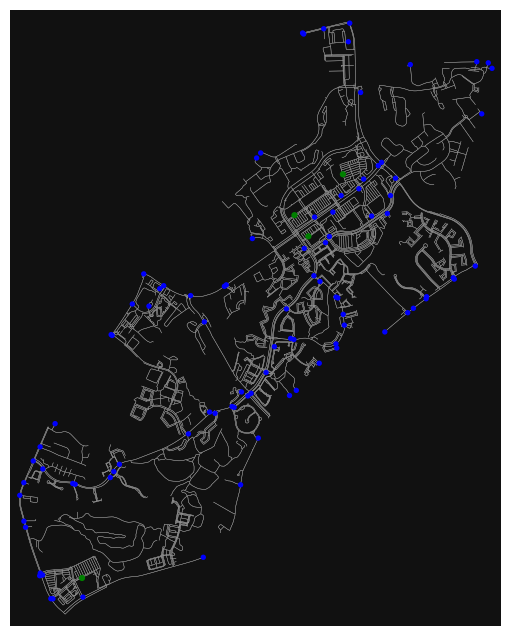

In [58]:
# Graph 2: Highlight our additional nodes
node_colors = []
node_sizes = []
store_nodes = set(stores["nearest_node"])
stop_nodes = set(bus_stops["nearest_node"])

for node in walk_graph.nodes:
    if node in store_nodes:
        node_colors.append("green")
        node_sizes.append(20)
    elif node in stop_nodes:
        node_colors.append("blue")
        node_sizes.append(15)
    else:
        node_colors.append("gray")
        node_sizes.append(0)

fig, ax = ox.plot_graph(
    walk_graph, node_color=node_colors, node_size=node_sizes,
    edge_linewidth=0.3, show=True, close=False
)

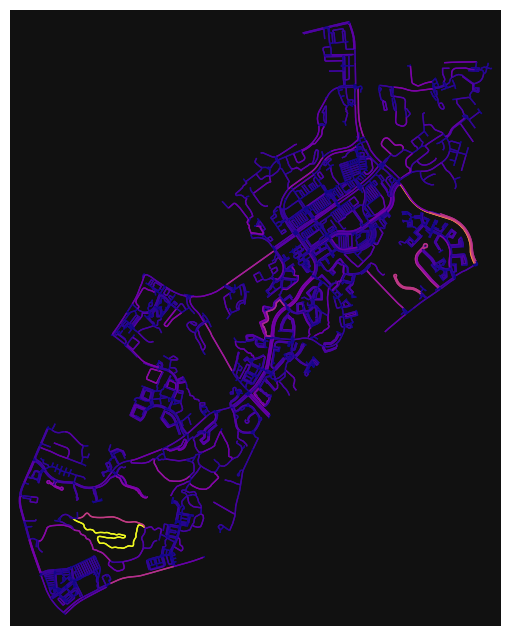

In [59]:
# Graph 3: Color the edges by walk time (purple - short -> yellow - long)
edge_colors = ox.plot.get_edge_colors_by_attr(walk_graph, "walk_time", cmap="plasma")
fig, ax = ox.plot_graph(walk_graph, edge_color=edge_colors, node_size=0, show=True, close=False)

In [63]:
tracts.drop(columns="centroid").head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,display_name,NAME_y,median_income,no_vehicle_households,population,state,county,tract,geometry,nearest_node
0,51,059,421103,51059421103,1400000US51059421103,4211.03,Census Tract 4211.03,G5020,S,4914488,...,"Kingstowne, Fairfax County, Virginia, United S...",4211.03,145865,29,6355,51,059,421103,"POLYGON ((-77.18626 38.73551, -77.18624 38.735...","(1560923233, 10964284853, 0)"
1,51,059,422403,51059422403,1400000US51059422403,4224.03,Census Tract 4224.03,G5020,S,2179011,...,"Kingstowne, Fairfax County, Virginia, United S...",4224.03,236012,0,3186,51,059,422403,"POLYGON ((-77.13327 38.76076, -77.13321 38.760...","(4697611879, 6929862323, 0)"
2,51,059,422402,51059422402,1400000US51059422402,4224.02,Census Tract 4224.02,G5020,S,1891110,...,"Kingstowne, Fairfax County, Virginia, United S...",4224.02,151451,54,4984,51,059,422402,"POLYGON ((-77.14577 38.7565, -77.14524 38.7568...","(8816014154, 8816014157, 0)"
3,51,059,421102,51059421102,1400000US51059421102,4211.02,Census Tract 4211.02,G5020,S,1564179,...,"Kingstowne, Fairfax County, Virginia, United S...",4211.02,150929,130,3611,51,059,421102,"POLYGON ((-77.16614 38.75164, -77.16567 38.752...","(11291553144, 11291553149, 0)"
4,51,059,422301,51059422301,1400000US51059422301,4223.01,Census Tract 4223.01,G5020,S,1290927,...,"Kingstowne, Fairfax County, Virginia, United S...",4223.01,156107,46,2642,51,059,422301,"POLYGON ((-77.13607 38.78407, -77.13434 38.784...","(2130235789, 2130235784, 0)"


In [65]:
# Graph 4: Interactive Map
import folium

edges_gdf = ox.graph_to_gdfs(walk_graph, nodes=False, edges=True)

map = folium.Map(location=[edges_gdf.union_all().centroid.y, edges_gdf.union_all().centroid.x], zoom_start=12)

folium.GeoJson(
    tracts.drop(columns="centroid"),
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#666666", "weight": 1},
).add_to(map)

folium.GeoJson(
    edges_gdf.to_crs(4326),
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#666666", "weight": 1}
    ).add_to(map)

for _, row in stores.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color="green",
        fill=True,
        popup=row.get("brand"),
    ).add_to(map)


for _, row in bus_stops.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=1.5,
        color="red",
        fill=True,
        popup=row.get("stop_name"),
    ).add_to(map)

map